## Portilla-Amaguaña et al. (2024) – HTC of Sugarcane Green Harvesting Residues

**Paper:** Hydrothermal Carbonization of Green Harvesting Residues (GHRs) from Sugar Cane: Effect of Temperature and Water/GHR Ratio on Mass and Energy Yield  
**DOI:** 10.1021/acsomega.4c01875  
**Journal:** ACS Omega

### Overview
This notebook ingests experimental data from the Portilla-Amaguaña 2024 study on hydrothermal carbonization (HTC) of sugarcane green harvesting residues. The paper reports:
- Feed characterization (proximate, ultimate analysis, HHV)
- HTC experiments at varying temperatures (180–321°C) and water/biomass ratios (5:1 to 10:1)
- Hydrochar yields, composition (C/H/O/N/S), and heating values
- Mass and energy yields on dry and dry-ash-free basis

### Notebook Structure
1. **Helper functions and schema**: Data ingestion utilities and canonical column definitions
2. **Methods and raw data tables**: Experimental methods and tabulated results from the paper
3. **Data ingestion**: Feed characterization and HTC run data parsing
4. **Quality assurance**: Energy/carbon balance checks, envelope plots, IC normalization
5. **Final output**: CSV export for master dataset integration

In [1]:
import pandas as pd, numpy as np, json
from pathlib import Path

COLUMNS = [
    "DOI","Provenance","Ref","Source_Figure",
    "Process_type","Process_subtype",
    "Feedstock","Family","Tier",
    "T","t","IC","Pressure","Solvent_or_medium","Reactor","Separation_method",'atmosphere',"Yield_basis",
    "Catalyst","Catalyst_Biomass_ratio","Heating_rate","Stirring_velocity","Water_Biomass_ratio",
    "Lignin","Cellulose_pct","Hemicellulose_pct","Extractives_pct",
    "C","H","O","N","S","Ash","O/C","H/C","HHV_input",
    "B_Y","C_Y","A_Y","G_Y","GW_Y",
    "E_B","E_H","C_B","C_H",
    "HHV_biooil","C_biooil","H_biooil","O_biooil","N_biooil","S_biooil",
    "HHV_biochar","C_biochar","H_biochar","O_biochar","N_biochar","S_biochar",
    "Moisture_min","Moisture_max",
    "Lignin_Rich","extra"
]
def _empty_row(): return {k: np.nan for k in COLUMNS}

def _family(feed:str)->str:
    s = (feed or "").lower()
    if any(x in s for x in ["straw","corn","rice","wheat","soy","herbaceous","tobacco"]): return "Ag residues / Herbaceous"
    if any(x in s for x in ["spruce","pine","fir"]): return "Woody Biomass / Softwood"
    if "poplar" in s or "eucalyptus" in s: return "Woody Biomass / Hardwood"
    if "mix" in s or "blend" in s: return "Woody Biomass / Mixed"
    return "Lignocellulosic / Other"

def _safe_json_load(obj):
    if isinstance(obj, dict): 
        return obj
    if isinstance(obj, str) and obj.strip():
        try:
            return json.loads(obj)
        except Exception:
            return {}
    return {}

def _btw_to_ic(s):
    """
    Convert biomass:water strings to biomass/water numeric ratio (IC).
    Examples: '1:10' -> 0.1 ; '1/15' -> 0.0667 ; '0.1' -> 0.1
    """
    if s is None: 
        return np.nan
    if isinstance(s, (int, float, np.integer, np.floating)):
        return float(s)
    txt = str(s).strip().replace(",", ".")
    if ':' in txt or '/' in txt:
        for sep in [':','/']:
            if sep in txt:
                a,b = txt.split(sep,1)
                try:
                    a = float(a.strip()); b = float(b.strip())
                    return a/b if b != 0 else np.nan
                except Exception:
                    return np.nan
    try:
        return float(txt)
    except Exception:
        return np.nan

def _oc(C,H,O):
    if pd.isna(C) or C<=0 or pd.isna(O): return np.nan
    return round((O/16.0)/(C/12.01), 3)

def _hc(C,H,O):
    if pd.isna(C) or C<=0 or pd.isna(H): return np.nan
    return round((H/1.008)/(C/12.01), 3)

def _isna(v): return v is None or (isinstance(v,(float,np.floating)) and np.isnan(v))

def _upsert(df, row, keys=("DOI","Feedstock","T","t","Catalyst","Solvent_or_medium","Source_Figure","Ref")):
    if df.empty: 
        return pd.DataFrame([row], columns=row.keys())
    mask = pd.Series(True, index=df.index)
    for k in keys:
        if k not in df.columns:
            df[k] = np.nan
        a = df[k].astype(object).where(~df[k].isna(), "__NA__")
        b = "__NA__" if _isna(row.get(k)) else str(row.get(k))
        mask &= (a.astype(str) == b)
    if mask.any():
        i = mask.idxmax()
        for k,v in row.items():
            if k in df.columns and not _isna(v):
                df.at[i,k] = v
        return df
    return pd.concat([df, pd.DataFrame([row])], ignore_index=True)

def add_feed(df, *, doi, prov, ref, feedstock,
             C=None,H=None,O=None,N=None,S=None,Ash=None, HHV_input=None,
             lignin=None,cell=None,hemi=None,extract=None, moisture=None, source_note="Feed table/text"):
    row = _empty_row()
    row.update(dict(
        DOI=doi, Provenance=prov, Ref=ref, Source_Figure=source_note,
        Process_type="Hydrothermal", Process_subtype=None,
        Feedstock=feedstock, Family=_family(feedstock), Tier="Experimental",
        Pressure=None, Solvent_or_medium=None, Reactor=None, Separation_method=None,
        Yield_basis="wt% of dry feedstock",
        C=C,H=H,O=O,N=N,S=S,Ash=Ash, HHV_input=HHV_input,
        Lignin=lignin, Cellulose_pct=cell, Hemicellulose_pct=hemi, Extractives_pct=extract,
        Moisture_min=moisture, Moisture_max=moisture,
        Lignin_Rich=True,
        extra=json.dumps({"provenance":{"doi":doi,"source":[source_note]}}, ensure_ascii=False)
    ))
    return _upsert(df, row, keys=("DOI","Feedstock","Ref"))

def add_or_patch_run(
    df, *,
    doi, prov, ref, source, feedstock,
    T=None, t_min=None, t_h=None, BTW=None, IC=None,
    catalyst=None, cat_wt_pct=None, solvent="Water", reactor=None, sep=None,
    process_subtype=None, yield_basis="wt% of dry feedstock",
    BY=None, CY=None, AY=None, GY=None, GWY=None,
    HHV_bo=None, C_bo=None, H_bo=None, O_bo=None, N_bo=None, S_bo=None,
    HHV_ch=None, C_ch=None, H_ch=None, O_ch=None, N_ch=None, S_ch=None,
    label=None, notes=None, extra=None, pressure_text=None,
    stirring_rpm=None, heating_rate=None, atmosphere=None 
):
    if t_min is None and t_h is not None: 
        t_min = float(t_h)*60.0
    if IC is None and BTW is not None: 
        IC = _btw_to_ic(BTW)

    row = _empty_row()
    row.update(dict(
        DOI=doi, Provenance=prov, Ref=ref, Source_Figure=source,
        Process_type="Hydrothermal",
        Process_subtype=(process_subtype or ("Catalytic" if catalyst else "Non-catalytic")),
        Feedstock=feedstock, Family=_family(feedstock), Tier="Experimental",
        T=(None if T is None else float(T)),
        t=(None if t_min is None else float(t_min)),
        IC=(None if IC is None else float(IC)),
        Pressure=pressure_text if pressure_text else "autogenic",
        Solvent_or_medium=solvent, Reactor=reactor, Separation_method=sep,
        atmosphere=atmosphere, 
        Yield_basis=yield_basis,
        Catalyst=(None if not catalyst else str(catalyst)),
        Catalyst_Biomass_ratio=(None if cat_wt_pct is None else float(cat_wt_pct)/100.0),
        Water_Biomass_ratio=(None if IC is None else round(1.0/float(IC),3)) if IC not in (None,0) else None,
        Heating_rate=heating_rate,
        Stirring_velocity=stirring_rpm,

        B_Y=None if BY is None else float(BY),
        C_Y=None if CY is None else float(CY),
        A_Y=None if AY is None else float(AY),
        G_Y=None if GY is None else float(GY),
        GW_Y=None if GWY is None else float(GWY),

        HHV_biooil=None if HHV_bo is None else float(HHV_bo),
        C_biooil=None if C_bo is None else float(C_bo),
        H_biooil=None if H_bo is None else float(H_bo),
        O_biooil=None if O_bo is None else float(O_bo),
        N_biooil=None if N_bo is None else float(N_bo),
        S_biooil=None if S_bo is None else float(S_bo),

        HHV_biochar=None if HHV_ch is None else float(HHV_ch),
        C_biochar=None if C_ch is None else float(C_ch),
        H_biochar=None if H_ch is None else float(H_ch),
        O_biochar=None if O_ch is None else float(O_ch),
        N_biochar=None if N_ch is None else float(N_ch),
        S_biochar=None if S_ch is None else float(S_ch),

        Lignin_Rich=True
    ))
    ex = {"label": label, "notes": notes}
    if extra: ex.update(extra)
    row["extra"] = json.dumps({k:v for k,v in ex.items() if v is not None}, ensure_ascii=False)
    return _upsert(df, row)

def _get_ER_pct(r):
    ex = _safe_json_load(r.get("extra"))
    er = ex.get("ER_pct")
    try:
        return float(er) if er is not None else np.nan
    except Exception:
        return np.nan

def finalize(df):
    out = df.copy()

    num_cols = [
        "B_Y","C_Y","A_Y","G_Y","GW_Y",
        "HHV_biooil","C_biooil","H_biooil","O_biooil","N_biooil","S_biooil",
        "HHV_biochar","C_biochar","H_biochar","O_biochar","N_biochar","S_biochar",
        "C","H","O","N","S","Ash","T","t","IC","HHV_input"
    ]
    for c in num_cols:
        if c in out.columns:
            out[c] = pd.to_numeric(out[c], errors="coerce")

    for i,r in out.iterrows():
        BY, CY = r.get("B_Y"), r.get("C_Y")
        HHV_bo, HHV_ch = r.get("HHV_biooil"), r.get("HHV_biochar")
        C_bo = r.get("C_biooil"); C_ch = r.get("C_biochar")

        Cf,Hf,Of = r.get("C"), r.get("H"), r.get("O")
        out.at[i,"O/C"] = _oc(Cf,Hf,Of); out.at[i,"H/C"] = _hc(Cf,Hf,Of)

        BY_ok = pd.notna(BY) and 0 <= BY <= 100
        CY_ok = pd.notna(CY) and 0 <= CY <= 100
        out.at[i,"E_B"] = (BY/100.0)*HHV_bo if BY_ok and pd.notna(HHV_bo) else np.nan
        out.at[i,"E_H"] = (CY/100.0)*HHV_ch if CY_ok and pd.notna(HHV_ch) else np.nan
        out.at[i,"C_B"] = (BY/100.0)*(C_bo/100.0) if BY_ok and pd.notna(C_bo) else np.nan
        out.at[i,"C_H"] = (CY/100.0)*(C_ch/100.0) if CY_ok and pd.notna(C_ch) else np.nan

        parts = [x for x in [BY, CY, r.get("A_Y"), r.get("G_Y")] if pd.notna(x)]
        ex = _safe_json_load(r.get("extra"))
        if parts:
            s = float(np.nansum(parts))
            ex.setdefault("QA", {})["mass_closure_sum_pct"] = round(s,2)
            ex["QA"]["Unassigned_or_over_pct"] = round(100.0 - s, 2)

        elems_bo = [r.get("C_biooil"), r.get("H_biooil"), r.get("O_biooil"), r.get("N_biooil"), r.get("S_biooil")]
        if any(pd.notna(x) for x in elems_bo):
            ex.setdefault("QA", {})["biooil_elem_sum_pct"] = round(float(np.nansum([x for x in elems_bo if pd.notna(x)])), 2)

        elems_ch = [r.get("C_biochar"), r.get("H_biochar"), r.get("O_biochar"), r.get("N_biochar"), r.get("S_biochar")]
        if any(pd.notna(x) for x in elems_ch):
            ex.setdefault("QA", {})["biochar_elem_sum_pct"] = round(float(np.nansum([x for x in elems_ch if pd.notna(x)])), 2)

        out.at[i,"extra"] = json.dumps(ex, ensure_ascii=False)
    return out

def propagate_and_clean(df):
    import math
    out = df.copy()
    feed_keys = ["C","H","O","N","S","Ash","HHV_input","Cellulose_pct","Hemicellulose_pct","Lignin","Extractives_pct"]
    feed_map = {}
    for feed, g in out.groupby("Feedstock", dropna=False):
        g1 = g[g["Source_Figure"].fillna("").str.contains("feed", case=False)]
        pick = g1.iloc[0] if not g1.empty else (g[(g["C"].notna()) & (g["H"].notna()) & (g["O"].notna())].iloc[0] if not g.empty else None)
        if pick is not None:
            feed_map[feed] = {k: pick.get(k, np.nan) for k in feed_keys}
    for idx, r in out.iterrows():
        feed = r.get("Feedstock")
        if feed in feed_map:
            for k,v in feed_map[feed].items():
                if k in out.columns and (pd.isna(out.at[idx,k]) or (isinstance(out.at[idx,k], float) and math.isnan(out.at[idx,k]))):
                    out.at[idx,k] = v
    out["O/C"] = [_oc(c,h,o) for c,h,o in zip(out.get("C"), out.get("H"), out.get("O"))]
    out["H/C"] = [_hc(c,h,o) for c,h,o in zip(out.get("C"), out.get("H"), out.get("O"))]
    out_cols = ["B_Y","C_Y","A_Y","G_Y","HHV_biooil","C_biooil","HHV_biochar","C_biochar"]
    for c in out_cols:
        if c not in out.columns:
            out[c] = np.nan
    has_out = out[out_cols].notna().any(axis=1)
    return out.loc[has_out].copy()

def propagate_feed_chem(df):
    out = df.copy()
    chem = ["C","H","O","N","S","Ash","HHV_input","Cellulose_pct","Hemicellulose_pct","Lignin","Extractives_pct"]
    feed_rows = {}
    for feed, g in out.groupby("Feedstock", dropna=False):
        gfeed = g[g["Source_Figure"].fillna("").str.contains("feed", case=False)]
        pick = gfeed.iloc[0] if not gfeed.empty else (g[(g["C"].notna()) & (g["H"].notna()) & (g["O"].notna())].iloc[0] if not g.empty else None)
        if pick is not None: feed_rows[feed] = pick
    for i,r in out.iterrows():
        pick = feed_rows.get(r.get("Feedstock"))
        if pick is None: continue
        for k in chem:
            if pd.isna(out.at[i,k]): out.at[i,k] = pick.get(k)
    out["O/C"] = [_oc(c,h,o) for c,h,o in zip(out.get("C"), out.get("H"), out.get("O"))]
    out["H/C"] = [_hc(c,h,o) for c,h,o in zip(out.get("C"), out.get("H"), out.get("O"))]
    return out

def attach_biochar_props(df, records):
    """
    records: iterable of dicts with keys:
      feedstock, T, t, HHV_biochar, C_biochar, [ref, source]
    """
    out = df.copy()
    for rec in records:
        m = (out["Feedstock"].astype(str)==str(rec["feedstock"])) & (out["T"]==float(rec["T"])) & (out["t"]==float(rec["t"]))
        idx = list(out[m].index)
        for i in idx:
            out.at[i,"HHV_biochar"] = rec.get("HHV_biochar", out.at[i,"HHV_biochar"])
            out.at[i,"C_biochar"] = rec.get("C_biochar", out.at[i,"C_biochar"])
            ex = _safe_json_load(out.at[i,"extra"])
            ex.setdefault("provenance_updates", []).append({k:rec[k] for k in ["ref","source"] if k in rec})
            out.at[i,"extra"] = json.dumps(ex, ensure_ascii=False)
    return finalize(out)

df = pd.DataFrame(columns=COLUMNS)

In [2]:
METHODS_Portilla2024 = {
    "Reactor": "Parr 4848 autoclave, 500 mL, stirred, with 4838 controller; agitation 300 rpm",
    "Separation": "After reaction, reactor cooled with internal cooling coil; "
                  "solid hydrochar separated by vacuum filtration, washed with deionized water, "
                  "dried at 105 °C for 24 h until constant weight",
    "Atmosphere": "Autogenous pressure (2–16 MPa, depending on T); no added gas",
    "Initial_pressure": "autogenic (no external pressurization, water only)",
    "Catalyst_default": None,
    "Catalyst_wt%_of_biomass": 0.0,
    "Solids_loading_wt%_daf": None,
    "IC_biomass_water": {"Ratios_tested": ["5/1", "7.5/1", "10/1"], "Basis": "w/w water:GHR"},
    "Experimental_design": "Central composite design (CCD), 2 factors (T, water/GHR ratio), "
                           "11 runs (4 factorial points, 4 axial points, 3 central replicates)",
    "Reaction_conditions": {
        "T_range_C": [180, 321],
        "t_min": 30.0,
    },
    "Feed_prep": "Sugar cane green harvesting residues (GHR) collected in Valle del Cauca (Colombia); "
                 "crushed, screened to avg. 0.356 mm particle size",
    "Analyses": {
        "Proximate": "ASTM D3302/D3302M-19 (moisture), ASTM D7582-15 (VM, ash), ASTM D3172-13 (FC)",
        "Ultimate": "ASTM D5373-21 (C, H, O, N), ASTM D4239-18e1 (S)",
        "HHV": "ASTM D5865/D5865M-19 (direct); Channiwala & Parikh correlation for comparison"
    },
    "Yield_calculations": {
        "Mass_yield": "Eq. 2–3, hydrochar mass / GHR mass (db, daf)",
        "Energy_yield": "Eq. 6, EY = MYdaf × HHVdaf(HTC)/HHVdaf(GHR)",
        "Energy_density": "Eq. 7, ED = EY / MYdaf"
    }
}

TABLE1_Feed_Proximate = {
    "GHR": {
        "Proximate_wt%_dry": {
            "Residual_moisture": 6.8,
            "VM": 73.7,
            "FC": 9.2,
            "Ash": 17.1
        },
        "HHV_kJkg": 16555,
        "HHV_MJkg": 16.555,
        "Notes": {"Basis": "dry (db)", "Ref": 52}
    },
    "Bagasse": {
        "Proximate_wt%_dry": {
            "Residual_moisture": 7.5,
            "VM": 78.7,
            "FC": 6.3,
            "Ash": 15.0
        },
        "HHV_kJkg": 16727,
        "HHV_MJkg": 16.727,
        "Notes": {"Basis": "dry (db)", "Ref": 52}
    },
    "Pith": {
        "Proximate_wt%_dry": {
            "Residual_moisture": 8.2,
            "VM": 86.1,
            "FC": 4.3,
            "Ash": 9.6
        },
        "HHV_kJkg": 16425,
        "HHV_MJkg": 16.425,
        "Notes": {"Basis": "dry (db)", "Ref": 52}
    }
}

TABLE2_GHR_Constituents = {
    "Buds": {
        "Proximate_wt%_dry": {
            "Residual_moisture": 6.04,
            "VM": 75.79,
            "FC": 16.62,
            "Ash": 7.59
        },
        "HHV_kJkg": 17922,
        "HHV_MJkg": 17.922,
        "Notes": {"Basis": "dry (db)", "Ref": 54}
    },
    "Green leaves": {
        "Proximate_wt%_dry": {
            "Residual_moisture": 6.22,
            "VM": 71.32,
            "FC": 18.29,
            "Ash": 10.39
        },
        "HHV_kJkg": 16946,
        "HHV_MJkg": 16.946,
        "Notes": {"Basis": "dry (db)", "Ref": 54}
    },
    "Dry leaves": {
        "Proximate_wt%_dry": {
            "Residual_moisture": 5.94,
            "VM": 72.90,
            "FC": 14.78,
            "Ash": 12.32
        },
        "HHV_kJkg": 16825,
        "HHV_MJkg": 16.825,
        "Notes": {"Basis": "dry (db)", "Ref": 54}
    }
}

TABLE4_GHR_HTC = {
    "GHR": {
        "Proximate_wt%_dry": {
            "Moisture": 8.5,
            "VM": 59.7,
            "Ash": 33.2,
            "FC": 7.1
        },
        "Ultimate_wt%_dry": {
            "C": 34.3,
            "H": 4.4,
            "N": 0.1,
            "O": 27.9,
            "S": 0.22
        },
        "HHV_MJkg": 12.6
    },
    "H-180-7.5": {
        "Proximate_wt%_dry": {"Moisture": 6.0, "VM": 64.1, "Ash": 26.7, "FC": 9.2},
        "Ultimate_wt%_dry": {"C": 39.9, "H": 4.6, "N": 0.3, "O": 28.4, "S": 0.08},
        "HHV_MJkg": 12.2
    },
    "H-200-5": {
        "Proximate_wt%_dry": {"Moisture": 5.0, "VM": 59.8, "Ash": 32.0, "FC": 8.2},
        "Ultimate_wt%_dry": {"C": 37.5, "H": 4.1, "N": 0.4, "O": 26.0, "S": 0.07},
        "HHV_MJkg": 15.4
    },
    "H-200-10": {
        "Proximate_wt%_dry": {"Moisture": 5.9, "VM": 68.8, "Ash": 22.4, "FC": 8.8},
        "Ultimate_wt%_dry": {"C": 43.5, "H": 4.9, "N": 0.6, "O": 28.6, "S": 0.07},
        "HHV_MJkg": 15.3
    },
    "H-250-4": {
        "Proximate_wt%_dry": {"Moisture": 2.2, "VM": 34.1, "Ash": 48.0, "FC": 17.9},
        "Ultimate_wt%_dry": {"C": 39.2, "H": 3.4, "N": 0.6, "O": 8.8, "S": 0.07},
        "HHV_MJkg": 14.7
    },
    "H-250-7.5": [
        {
            "Proximate_wt%_dry": {"Moisture": 2.4, "VM": 35.0, "Ash": 52.0, "FC": 13.0},
            "Ultimate_wt%_dry": {"C": 36.2, "H": 3.3, "N": 0.5, "O": 8.0, "S": 0.08},
            "HHV_MJkg": 12.8
        },
        {
            "Proximate_wt%_dry": {"Moisture": 1.8, "VM": 24.3, "Ash": 68.4, "FC": 7.3},
            "Ultimate_wt%_dry": {"C": 20.5, "H": 2.0, "N": 0.4, "O": 8.7, "S": 0.06},
            "HHV_MJkg": 7.6
        },
        {
            "Proximate_wt%_dry": {"Moisture": 2.1, "VM": 24.2, "Ash": 69.4, "FC": 6.4},
            "Ultimate_wt%_dry": {"C": 23.8, "H": 2.3, "N": 0.5, "O": 4.0, "S": 0.08},
            "HHV_MJkg": 8.8
        }
    ],
    "H-250-11": {
        "Proximate_wt%_dry": {"Moisture": 2.2, "VM": 39.0, "Ash": 44.3, "FC": 16.7},
        "Ultimate_wt%_dry": {"C": 40.2, "H": 3.5, "N": 0.5, "O": 11.4, "S": 0.08},
        "HHV_MJkg": 15.0
    },
    "H-300-5": {
        "Proximate_wt%_dry": {"Moisture": 1.2, "VM": 23.7, "Ash": 62.8, "FC": 13.5},
        "Ultimate_wt%_dry": {"C": 32.3, "H": 2.6, "N": 0.4, "O": 1.8, "S": 0.08},
        "HHV_MJkg": 16.2
    },
    "H-300-10": {
        "Proximate_wt%_dry": {"Moisture": 1.4, "VM": 29.2, "Ash": 50.2, "FC": 20.6},
        "Ultimate_wt%_dry": {"C": 42.1, "H": 3.3, "N": 0.6, "O": 3.8, "S": 0.09},
        "HHV_MJkg": 14.3
    },
    "H-321-7.5": {
        "Proximate_wt%_dry": {"Moisture": 1.2, "VM": 28.0, "Ash": 52.4, "FC": 19.6},
        "Ultimate_wt%_dry": {"C": 47.2, "H": 3.7, "N": 0.6, "O": 0.0, "S": 0.08},
        "HHV_MJkg": None
    }
}

TABLE5_HTC_Performance = {
    "GHR": {
        "Experimental_Yield_pct": None,
        "Mass_Yield_db_pct": None,
        "Mass_Yield_daf_pct": None,
        "Energy_Efficiency_daf_pct": None,
        "Fuel_Ratio_CF_VM_db": 0.12,
        "Energy_Density": None,
        "H_C": 1.52,
        "O_C": 0.61
    },
    "H-180-7.5": {
        "Experimental_Yield_pct": 65.3,
        "Mass_Yield_db_pct": 67.1,
        "Mass_Yield_daf_pct": 71.65,
        "Energy_Efficiency_daf_pct": 63.03,
        "Fuel_Ratio_CF_VM_db": 0.14,
        "Energy_Density": 0.88,
        "H_C": 1.40,
        "O_C": 0.54
    },
    "H-200-5": {
        "Experimental_Yield_pct": 64.3,
        "Mass_Yield_db_pct": 66.7,
        "Mass_Yield_daf_pct": 65.42,
        "Energy_Efficiency_daf_pct": 78.71,
        "Fuel_Ratio_CF_VM_db": 0.14,
        "Energy_Density": 1.20,
        "H_C": 1.31,
        "O_C": 0.52
    },
    "H-200-10": {
        "Experimental_Yield_pct": 60.8,
        "Mass_Yield_db_pct": 62.5,
        "Mass_Yield_daf_pct": 70.54,
        "Energy_Efficiency_daf_pct": 73.77,
        "Fuel_Ratio_CF_VM_db": 0.13,
        "Energy_Density": 1.05,
        "H_C": 1.35,
        "O_C": 0.49
    },
    "H-250-4": {
        "Experimental_Yield_pct": 52.3,
        "Mass_Yield_db_pct": 55.9,
        "Mass_Yield_daf_pct": 40.71,
        "Energy_Efficiency_daf_pct": 61.17,
        "Fuel_Ratio_CF_VM_db": 0.52,
        "Energy_Density": 1.50,
        "H_C": 1.03,
        "O_C": 0.17
    },
    "H-250-7.5": [
        {
            "Experimental_Yield_pct": 65.5,
            "Mass_Yield_db_pct": 69.8,
            "Mass_Yield_daf_pct": 47.05,
            "Energy_Efficiency_daf_pct": 66.34,
            "Fuel_Ratio_CF_VM_db": 0.37,
            "Energy_Density": 1.41,
            "H_C": 1.08,
            "O_C": 0.16
        },
        {
            "Experimental_Yield_pct": 62.4,
            "Mass_Yield_db_pct": 67.0,
            "Mass_Yield_daf_pct": 29.49,
            "Energy_Efficiency_daf_pct": 37.57,
            "Fuel_Ratio_CF_VM_db": 0.30,
            "Energy_Density": 1.27,
            "H_C": 1.19,
            "O_C": 0.32
        },
        {
            "Experimental_Yield_pct": 54.9,
            "Mass_Yield_db_pct": 58.7,
            "Mass_Yield_daf_pct": 25.10,
            "Energy_Efficiency_daf_pct": 38.44,
            "Fuel_Ratio_CF_VM_db": 0.26,
            "Energy_Density": 1.53,
            "H_C": 1.16,
            "O_C": 0.13
        }
    ],
    "H-250-11": {
        "Experimental_Yield_pct": 49.9,
        "Mass_Yield_db_pct": 53.3,
        "Mass_Yield_daf_pct": 41.56,
        "Energy_Efficiency_daf_pct": 59.35,
        "Fuel_Ratio_CF_VM_db": 0.43,
        "Energy_Density": 1.43,
        "H_C": 1.06,
        "O_C": 0.21
    },
    "H-300-5": {
        "Experimental_Yield_pct": 54.2,
        "Mass_Yield_db_pct": 58.5,
        "Mass_Yield_daf_pct": 30.16,
        "Energy_Efficiency_daf_pct": 69.59,
        "Fuel_Ratio_CF_VM_db": 0.57,
        "Energy_Density": 2.31,
        "H_C": 0.96,
        "O_C": 0.04
    },
    "H-300-10": {
        "Experimental_Yield_pct": 45.1,
        "Mass_Yield_db_pct": 48.6,
        "Mass_Yield_daf_pct": 33.63,
        "Energy_Efficiency_daf_pct": 51.21,
        "Fuel_Ratio_CF_VM_db": 0.70,
        "Energy_Density": 1.52,
        "H_C": 0.94,
        "O_C": 0.07
    },
    "H-321-7.5": {
        "Experimental_Yield_pct": 46.7,
        "Mass_Yield_db_pct": 50.4,
        "Mass_Yield_daf_pct": 33.28,
        "Energy_Efficiency_daf_pct": 53.79,
        "Fuel_Ratio_CF_VM_db": 0.70,
        "Energy_Density": None,
        "H_C": None,
        "O_C": None
    }
}

TABLE7_Polymeric_Composition = {
    "GHR": {
        "Cellulose": 0.36,
        "Hemicellulose": 0.24,
        "Lignin_O": 0.11,
        "Lignin_C": 0.08,
        "Lignin_H": 0.21
    },
    "H-180-7.5": {
        "Cellulose": 0.25,
        "Hemicellulose": 0.16,
        "Lignin_O": 0.22,
        "Lignin_C": 0.12,
        "Lignin_H": 0.25
    },
    "H-200-5": {
        "Cellulose": 0.19,
        "Hemicellulose": 0.13,
        "Lignin_O": 0.32,
        "Lignin_C": 0.13,
        "Lignin_H": 0.22
    },
    "H-200-10": {
        "Cellulose": 0.17,
        "Hemicellulose": 0.12,
        "Lignin_O": 0.53,
        "Lignin_C": 0.14,
        "Lignin_H": 0.04
    }
}

In [3]:
doi  = "10.1021/acsomega.4c01875"
ref  = "Portilla-Amaguaña 2024 — ACS Omega"
paper_title = "Hydrothermal Carbonization of Green Harvesting Residues (GHRs) from Sugar Cane"

prov = ("Feed ultimate/ash & HHV from Table 4 (db); hydrochar ultimate (C/H/O/N/S) "
        "& HHV from Table 4 (db); hydrochar mass yield (db) from Table 5; "
        "operating details from Methods §2.1–2.3 (Parr 4848, 30 min, water medium, autogenic).")

def _parse_htc_key(k: str):
    """'H-200-10' -> (T_C=200.0, water_ratio=10.0); 'GHR' -> (None, None)."""
    s = str(k).strip()
    if s.upper() == "GHR":
        return None, None
    try:
        _, t_str, r_str = s.split("-")
        return float(t_str), float(r_str)
    except Exception:
        return None, None

def _ic_from_water_ratio(r):
    try:
        r = float(r)
        return round(1.0/r, 6) if r>0 else np.nan
    except Exception:
        return np.nan

U0 = TABLE4_GHR_HTC["GHR"]["Ultimate_wt%_dry"]
P0 = TABLE1_Feed_Proximate["GHR"]["Proximate_wt%_dry"]
df = add_feed(
    df,
    doi=doi, prov=prov, ref=ref, feedstock="Sugarcane GHR",
    C=U0.get("C"), H=U0.get("H"), O=U0.get("O"), N=U0.get("N"), S=U0.get("S"),
    Ash=P0.get("Ash"), HHV_input=TABLE1_Feed_Proximate["GHR"]["HHV_MJkg"],
    lignin=None, cell=None, hemi=None, extract=None, moisture=P0.get("Residual_moisture"),
    source_note="Tables 1 & 4 — feed characterization"
)

m_feed = (df["DOI"]==doi) & (df["Feedstock"]=="Sugarcane GHR") & (df["Source_Figure"]=="Tables 1 & 4 — feed characterization")
df.loc[m_feed, ["Family","Tier","Lignin_Rich"]] = ["Ag residues / Herbaceous", "Experimental", False]
df.loc[m_feed, "extra"] = df.loc[m_feed, "extra"].apply(
    lambda x: json.dumps({**_safe_json_load(x),
                          "Paper_Title": paper_title,
                          "Methods": METHODS_Portilla2024},
                         ensure_ascii=False)
)

t4_norm = []
for k, rec in TABLE4_GHR_HTC.items():
    if k == "GHR":
        continue
    T_C, water_ratio = _parse_htc_key(k)
    IC = _ic_from_water_ratio(water_ratio)
    if isinstance(rec, list):
        for idx, sub in enumerate(rec, start=1):
            t4_norm.append({
                "key": k, "split": idx,
                "T": T_C, "ratio": water_ratio, "IC": IC,
                "Ult": sub.get("Ultimate_wt%_dry") or {},
                "Prox": sub.get("Proximate_wt%_dry") or {},
                "HHV_char": sub.get("HHV_MJkg"),
            })
    else:
        t4_norm.append({
            "key": k, "split": None,
            "T": T_C, "ratio": water_ratio, "IC": IC,
            "Ult": rec.get("Ultimate_wt%_dry") or {},
            "Prox": rec.get("Proximate_wt%_dry") or {},
            "HHV_char": rec.get("HHV_MJkg"),
        })

t5_map = {}
for k, v in TABLE5_HTC_Performance.items():
    if k == "GHR":
        continue
    if isinstance(v, list):
        t5_map[k] = [{"split": i+1, **vi} for i, vi in enumerate(v)]
    elif isinstance(v, dict):
        t5_map[k] = [{"split": None, **v}]
    else:
        t5_map[k] = []

for rec in t4_norm:
    key = rec["key"]
    T = rec["T"]
    t_min = METHODS_Portilla2024["Reaction_conditions"]["t_min"]
    IC = rec["IC"]; ratio = rec["ratio"]
    split = rec["split"]

    t5_list = t5_map.get(key, [])
    t5_hit = next((c for c in t5_list if c.get("split")==split), None)
    CY = (t5_hit or {}).get("Mass_Yield_db_pct")

    u = rec["Ult"]
    hhv_ch = rec["HHV_char"]

    extra_payload = {
        "water_to_GHR_ratio_w_w": ratio,
        "Proximate_char": rec.get("Prox"),
        "Ultimate_char": u,
        "Table5_metrics": {
            "Experimental_Yield_pct": (t5_hit or {}).get("Experimental_Yield_pct"),
            "Mass_Yield_db_pct": CY,
            "Mass_Yield_daf_pct": (t5_hit or {}).get("Mass_Yield_daf_pct"),
            "Energy_Efficiency_daf_pct": (t5_hit or {}).get("Energy_Efficiency_daf_pct"),
            "Fuel_Ratio_CF_VM_db": (t5_hit or {}).get("Fuel_Ratio_CF_VM_db"),
            "Energy_Density": (t5_hit or {}).get("Energy_Density"),
            "H/C_from_T5": (t5_hit or {}).get("H_C"),
            "O/C_from_T5": (t5_hit or {}).get("O_C"),
        },
        "Split_index": split,
        "Methods": METHODS_Portilla2024
    }

    df = add_or_patch_run(
        df,
        doi=doi, prov=prov, ref=ref,
        source="Tables 4 & 5 — HTC char composition and yields",
        feedstock="Sugarcane GHR",
        process_subtype="Non-catalytic (HTC)",
        T=T, t_min=t_min, IC=IC,
        catalyst=None, cat_wt_pct=None,
        solvent="Water",
        reactor=METHODS_Portilla2024["Reactor"],
        sep="Vacuum filtration; DI wash; oven 105 °C 24 h",
        atmosphere="autogenic",
        pressure_text=METHODS_Portilla2024["Initial_pressure"],
        BY=None, AY=None, GY=None, CY=CY,
        HHV_ch=hhv_ch,
        C_ch=u.get("C"), H_ch=u.get("H"), O_ch=u.get("O"), N_ch=u.get("N"), S_ch=u.get("S"),
        HHV_bo=None, C_bo=None,
        notes=f"HTC run {key} (water:GHR={ratio}:1, 30 min, autogenic).",
        extra=extra_payload,
        label=f"{key}" + (f"-r{split}" if split else "")
    )

for k, comp in TABLE7_Polymeric_Composition.items():
    if k == "GHR":
        m = (df["DOI"]==doi) & (df["Feedstock"]=="Sugarcane GHR")
    else:
        T_C, ratio = _parse_htc_key(k)
        m = ((df["DOI"]==doi) & (df["Feedstock"]=="Sugarcane GHR") &
             (df["T"]==float(T_C)) & (df["Water_Biomass_ratio"]==round(float(ratio),3)))
    df.loc[m, "extra"] = df.loc[m, "extra"].apply(
        lambda x: json.dumps({**_safe_json_load(x), "Polymeric_Composition": comp}, ensure_ascii=False)
    )

mask_all = (df["DOI"]==doi)
df.loc[mask_all, "extra"] = df.loc[mask_all, "extra"].apply(
    lambda x: json.dumps({**_safe_json_load(x),
                          "Paper_Title": paper_title,
                          "Provenance_note": prov},
                         ensure_ascii=False)
)

df = propagate_feed_chem(df)
df=propagate_and_clean(df)
df = finalize(df)

cols_show = ["Feedstock","T","t","IC","C_Y",
             "HHV_biochar","C_biochar","H_biochar","O_biochar","N_biochar","S_biochar",
             "Ash","O/C","H/C"]
display_df = df.loc[mask_all, cols_show].sort_values(["T","Feedstock"]).reset_index(drop=True)
print(display_df.to_string(index=False))

df["Yield_basis"] = "wt% dry basis (db)"
csv_path = "./CSVs/Portilla_2024_ACS_Omega_HTC.csv"
Path(csv_path).parent.mkdir(parents=True, exist_ok=True)
df.to_csv(csv_path, index=False)
print(f"Saved:  | rows={len(df)}")

    Feedstock     T    t       IC  C_Y  HHV_biochar  C_biochar  H_biochar  O_biochar  N_biochar  S_biochar  Ash   O/C   H/C
Sugarcane GHR 180.0 30.0 0.133333 67.1         12.2       39.9        4.6       28.4        0.3       0.08 17.1 0.611 1.528
Sugarcane GHR 200.0 30.0 0.100000 62.5         15.3       43.5        4.9       28.6        0.6       0.07 17.1 0.611 1.528
Sugarcane GHR 250.0 30.0 0.090909 53.3         15.0       40.2        3.5       11.4        0.5       0.08 17.1 0.611 1.528
Sugarcane GHR 300.0 30.0 0.100000 48.6         14.3       42.1        3.3        3.8        0.6       0.09 17.1 0.611 1.528
Sugarcane GHR 321.0 30.0 0.133333 50.4          NaN       47.2        3.7        0.0        0.6       0.08 17.1 0.611 1.528
Saved:  | rows=5


/tmp/ipykernel_1279009/3476660191.py:89: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  return pd.concat([df, pd.DataFrame([row])], ignore_index=True)


In [4]:
n_EB = df["E_B"].notna().sum()
n_CB = df["C_B"].notna().sum()
n_EH = df["E_H"].notna().sum()
n_CH = df["C_H"].notna().sum()
print(f"E_H filled rows: {n_EH} | C_H filled rows: {n_CH}")
print(f"E_B filled rows: {n_EB} | C_B filled rows: {n_CB}")

E_H filled rows: 4 | C_H filled rows: 5
E_B filled rows: 0 | C_B filled rows: 0


In [5]:
mask = (df["DOI"]=="10.1016/j.biombioe.2025.107671")
print("E_B rows:")
print(df.loc[mask & df["E_B"].notna(), ["Feedstock","T","t","Catalyst","B_Y","HHV_biooil","E_B"]])
print("\nC_B rows:")
print(df.loc[mask & df["C_B"].notna(), ["Feedstock","T","t","Catalyst","B_Y","C_biooil","C_B"]])

E_B rows:
Empty DataFrame
Columns: [Feedstock, T, t, Catalyst, B_Y, HHV_biooil, E_B]
Index: []

C_B rows:
Empty DataFrame
Columns: [Feedstock, T, t, Catalyst, B_Y, C_biooil, C_B]
Index: []


In [6]:
len(df)

5

E_H > 25.0 MJ/kg: 0 rows
E_B > 25.0 MJ/kg: 0 rows
B_Y outside [0,100]: 0 rows
C_Y outside [0,100]: 0 rows
C_B > 0.60 (fraction): 0 rows
C_H > 0.65 (fraction): 0 rows
HHV_input < 12 MJ/kg: 0 rows
H/C outside ~[0.8,1.9]: 0 rows
O/C outside ~[0.35,0.95]: 0 rows
No data to plot for E_B.


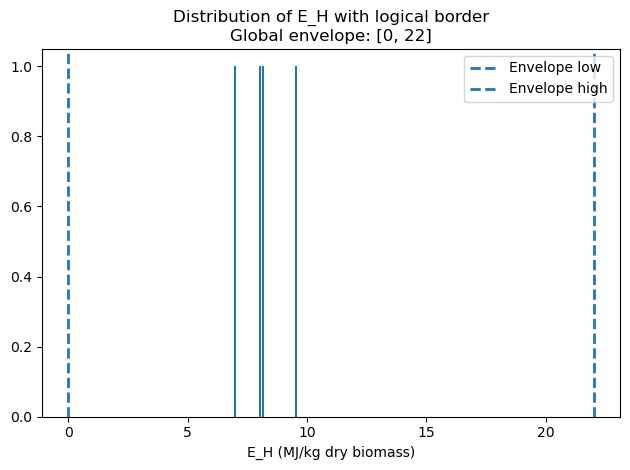

No data to plot for C_B.


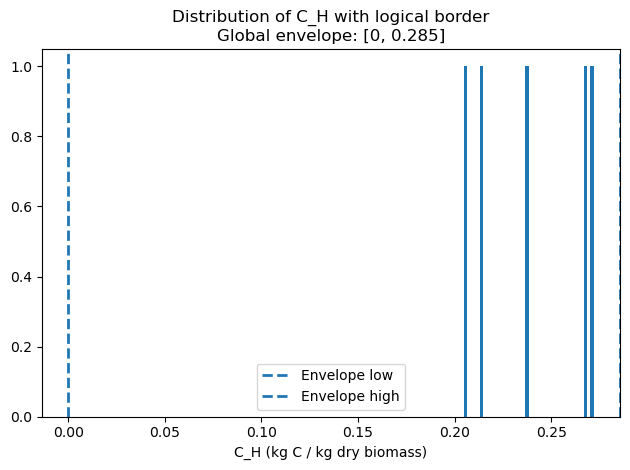

No data to plot for B_Y.


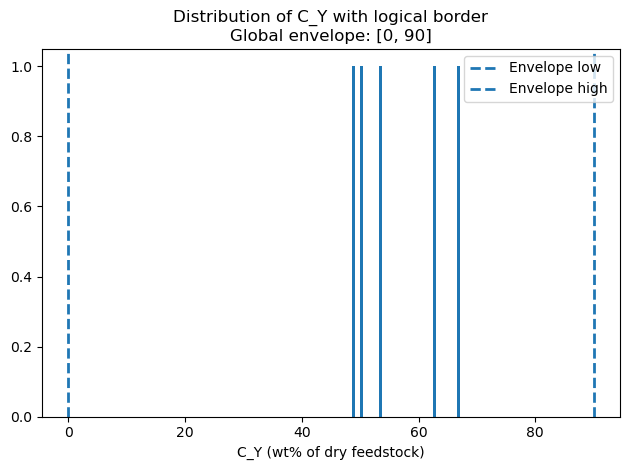

No data to plot for A_Y.
No data to plot for G_Y.


In [7]:
import importlib.util, pathlib, sys

mod_path = pathlib.Path("../../modules/qa_envelopes.py").resolve() 
spec = importlib.util.spec_from_file_location("qa_envelopes", str(mod_path))
qa_envelopes = importlib.util.module_from_spec(spec)
sys.modules["qa_envelopes"] = qa_envelopes
spec.loader.exec_module(qa_envelopes)

qa_envelopes.run_basic_qc(df)
qa_envelopes.plot_energy_carbon_envelopes(df)
qa_envelopes.plot_yield_envelopes(df)

In [8]:
df, ic_audit = qa_envelopes.homogenize_ic_to_percent(
    df,
    bounds=(0.5, 40.0),
    prefer_wbr=True,
    diff_tol_pp=1.0,
    inplace=False,
    dedupe_by_paper=True
)

print(
    ic_audit.sort_values(
        ["rows_out_of_bounds","rows_disagree_wbr","rows_used_wbr"], ascending=False
    ).to_string(index=False)
)

IC homogenization: rows=5, with W/B=5, filled_from_W/B=0, disagreed>1.0pp=2, out_of_bounds[0.5,40.0]=0
             paper_title  rows_total  rows_with_IC_raw  rows_with_WB  rows_used_wbr  rows_disagree_wbr  rows_out_of_bounds  IC_min    IC_max  IC_median  IC_wbr_min  IC_wbr_max
10.1021/acsomega.4c01875           5                 5             5              2                  2                   0  9.0909 11.764706       10.0    8.333333   11.764706


In [9]:
mask = (df["DOI"]=="10.1021/acsomega.4c01875") & (df["Feedstock"]=="Sugarcane GHR")

debug_cols = ["Feedstock","T","t","IC","C_Y","HHV_biochar","C_biochar","E_H","C_H","extra"]
dbg = df.loc[mask, debug_cols].copy()

dbg["E_H_reason"] = np.where(dbg["E_H"].notna(), "",
                             np.where(dbg["HHV_biochar"].isna(), "no HHV_biochar",
                             np.where(dbg["C_Y"].isna(), "no C_Y", "")))
dbg["C_H_reason"] = np.where(dbg["C_H"].notna(), "",
                             np.where(dbg["C_biochar"].isna(), "no C_biochar",
                             np.where(dbg["C_Y"].isna(), "no C_Y", "")))

print("Counts:",
      "E_H", dbg["E_H"].notna().sum(),
      "C_H", dbg["C_H"].notna().sum(),
      "E_B", df.loc[mask, "E_B"].notna().sum(),
      "C_B", df.loc[mask, "C_B"].notna().sum())

print(dbg.loc[(dbg["E_H"].isna()) | (dbg["C_H"].isna()),
              ["T","IC","C_Y","HHV_biochar","C_biochar","E_H_reason","C_H_reason"]].to_string(index=False))

Counts: E_H 4 C_H 5 E_B 0 C_B 0
    T        IC  C_Y  HHV_biochar  C_biochar     E_H_reason C_H_reason
321.0 11.764706 50.4          NaN       47.2 no HHV_biochar           


In [10]:
Paper_Title="Hydrothermal Carbonization of Green Harvesting Residues (GHRs) from Sugar Cane: Effect of Temperature and Water/GHR Ratio on Mass and Energy Yield"
df["Paper_Title"] = Paper_Title
out_path_csv = Path("./CSVs/Portilla_2024_ACS_Omega_HTC.csv")
df.to_csv(out_path_csv, index=False)

In [11]:
import pandas as pd, numpy as np, json

def _first(s):
    try:
        v = s.dropna().astype(str).unique().tolist()
        return v[0] if v else "—"
    except Exception:
        return "—"

try:
    this_doi = PAPER_META.get("DOI")
except NameError:
    this_doi = None
if not this_doi and 'DOI' in df.columns:
    u = df['DOI'].dropna().astype(str).unique().tolist()
    this_doi = u[0] if u else None

mask = (df['DOI'].astype(str) == str(this_doi)) if (this_doi and 'DOI' in df.columns) else pd.Series(True, index=df.index)

print("DOI:", _first(df.loc[mask, 'DOI']) if 'DOI' in df.columns else '—')
print("Title:", _first(df.loc[mask, 'Paper_Title']) if 'Paper_Title' in df.columns else '—')
print("Provenance:", _first(df.loc[mask, 'Provenance']) if 'Provenance' in df.columns else '—')

def build_view(data, base_cols, comp_cols, sort_cols=("T","t")):
    cols_present = [c for c in base_cols if c in data.columns]
    view = data.loc[:, cols_present].copy()
    for c in comp_cols:
        view[c] = data[c] if c in data.columns else np.nan
    view = view[cols_present + comp_cols].dropna(how='all', subset=comp_cols)
    if all(c in view.columns for c in sort_cols):
        view = view.sort_values(list(sort_cols))
    return view

bo = build_view(df.loc[mask], [c for c in ('T','t') if c in df.columns],
                ['C_biooil','H_biooil','O_biooil','N_biooil','S_biooil','HHV_biooil'])
print("\nBio-oil composition & HHV (C/H/O/N/S, MJ/kg):")
print(bo.to_string(index=False) if not bo.empty else "(none)")

bc = build_view(df.loc[mask], [c for c in ('T','t') if c in df.columns],
                ['C_biochar','H_biochar','O_biochar','N_biochar','S_biochar','HHV_biochar'])
print("\nBiochar composition & HHV (C/H/O/N/S, MJ/kg):")
print(bc.to_string(index=False) if not bc.empty else "(none)")

DOI: 10.1021/acsomega.4c01875
Title: Hydrothermal Carbonization of Green Harvesting Residues (GHRs) from Sugar Cane: Effect of Temperature and Water/GHR Ratio on Mass and Energy Yield
Provenance: Feed ultimate/ash & HHV from Table 4 (db); hydrochar ultimate (C/H/O/N/S) & HHV from Table 4 (db); hydrochar mass yield (db) from Table 5; operating details from Methods §2.1–2.3 (Parr 4848, 30 min, water medium, autogenic).

Bio-oil composition & HHV (C/H/O/N/S, MJ/kg):
(none)

Biochar composition & HHV (C/H/O/N/S, MJ/kg):
    T    t  C_biochar  H_biochar  O_biochar  N_biochar  S_biochar  HHV_biochar
180.0 30.0       39.9        4.6       28.4        0.3       0.08         12.2
200.0 30.0       43.5        4.9       28.6        0.6       0.07         15.3
250.0 30.0       40.2        3.5       11.4        0.5       0.08         15.0
300.0 30.0       42.1        3.3        3.8        0.6       0.09         14.3
321.0 30.0       47.2        3.7        0.0        0.6       0.08          NaN
